<a href="https://colab.research.google.com/github/hommedesbois/HSF-deep-learning/blob/main/diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install diffusers transformers accelerate peft

In [2]:
from google.colab import userdata
from huggingface_hub import login

try:
    # Added .strip() to remove hidden newline characters (\r\n)
    hf_token = userdata.get('HF_TOKEN').strip()
    login(token=hf_token)
    print('Successfully logged into Hugging Face!')
except Exception as e:
    print(f'Authentication failed: {e}. Please check your HF_TOKEN in Colab secrets.')

Successfully logged into Hugging Face!


In [3]:
import torch
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import load_image
from google.colab import userdata

# Loading the 'Turbo' model with authentication
pipe = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16,
    variant="fp16",
    token=userdata.get('HF_TOKEN')
).to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/5 [00:00<?, ?it/s]

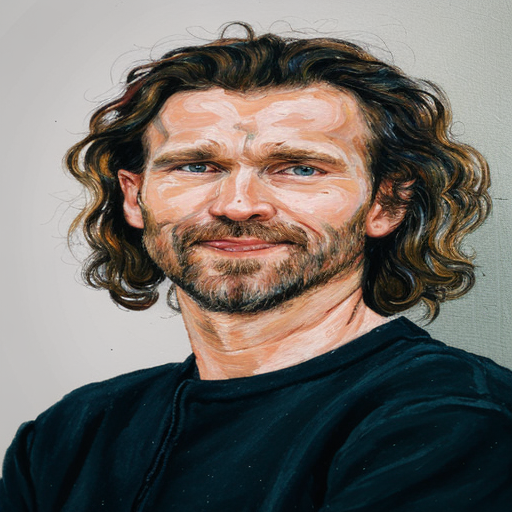

In [4]:
from diffusers.utils import load_image
import os

# Provide the path to the image you uploaded to Colab
image_path = "/content/tobias.JPG"

if os.path.exists(image_path):
    # Load and resize the initial image
    init_image = load_image(image_path).resize((512, 512))

    # Define the style prompt
    prompt = "a vibrant oil painting in the style of Van Gogh"

    # With num_inference_steps=10, we can now use a lower strength like 0.5
    result = pipe(
        prompt,
        image=init_image,
        strength=0.5,
        guidance_scale=0.0,
        num_inference_steps=10
    ).images[0]

    # Display the final result
    display(result)
else:
    print(f"File not found at {image_path}. Please upload your image to the Colab file browser (📁 icon on the left).")